# Build and train MicNet


In [1]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys
import skimage
import skimage.io
import skimage.transform
import skimage
import skimage.io
import tifffile

import time
import torch
import torch.hub
import torch.nn

from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion

/project/DPDS/Xiao_lab/shared/qin_zhou/environments/envs/MicNet/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load data

(25219, 27482, 3)


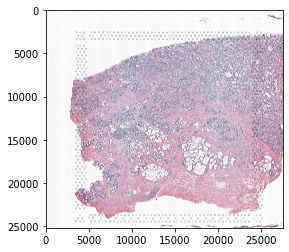

In [3]:
image_file = "./Sample_data/Dataset_HPC/Visium_FFPE_Human_Prostate_Cancer_image.tif"
image = tifffile.imread(os.path.join(image_file))
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [4]:
count_stat = pd.read_csv("./output/Dataset_HPC/1_count_stat_prostate.csv", index_col=0)
count = pd.read_csv("./output/Dataset_HPC/1_pd_count_norm_prostate.csv", index_col=0)

In [5]:
transformation_file = "./output/Dataset_HPC/location_prostate_cancer.csv"
pd_meta = pd.read_table(transformation_file, index_col=0, sep=",")
print(pd_meta.shape)
print(count.shape)

(4371, 2)
(4371, 16905)


In [11]:
# Split training and testing
np.random.seed(12345)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.8), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3496, #Testing: 875


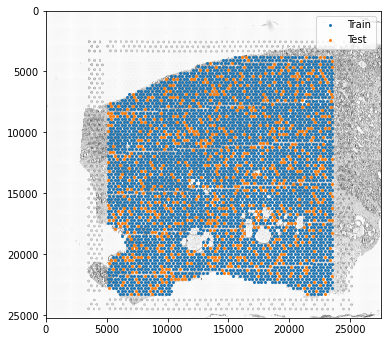

In [12]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm[..., 0], cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Y"].values
coords_y = pd_meta.loc[training_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Y"].values
coords_y = pd_meta.loc[testing_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [13]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [14]:
count

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
AAACAAGTATCTCCCA-1,0.0,0.0,0.061642,0.0,0.0,0.076771,0.0,0.000000,0.081303,0.0,...,0.000000,0.000000,0.0,0.0,0.083997,0.000000,0.000000,0.000000,0.064032,0.089783
AAACACCAATAACTGC-1,0.0,0.0,0.065567,0.0,0.0,0.079576,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.076679,0.000000,0.088829,0.064782,0.068214
AAACAGAGCGACTCCT-1,0.0,0.0,0.056247,0.0,0.0,0.069159,0.0,0.065647,0.000000,0.0,...,0.000000,0.069181,0.0,0.0,0.090637,0.000000,0.000000,0.077326,0.046978,0.085669
AAACAGCTTTCAGAAG-1,0.0,0.0,0.072811,0.0,0.0,0.069734,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.085881,0.075472,0.092524,0.077961,0.057079,0.075610
AAACAGGGTCTATATT-1,0.0,0.0,0.075066,0.0,0.0,0.000000,0.0,0.074046,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.103097,0.000000,0.053192,0.075078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0.0,0.0,0.067912,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.072082,0.0,0.0,0.000000,0.077969,0.000000,0.080532,0.058602,0.069375
TTGTTTCACATCCAGG-1,0.0,0.0,0.069299,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.088432,0.074192,0.0,0.0,0.081177,0.080233,0.000000,0.082863,0.056570,0.071414
TTGTTTCATTAGTCTA-1,0.0,0.0,0.000000,0.0,0.0,0.083564,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.057173,0.000000
TTGTTTCCATACAACT-1,0.0,0.0,0.073296,0.0,0.0,0.000000,0.0,0.078321,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.062164,0.000000


In [15]:
PATCH_SIZE = 256

## 2) Check data loader

In [16]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

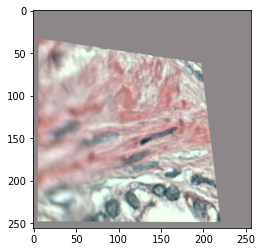

tensor([2068])


In [17]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

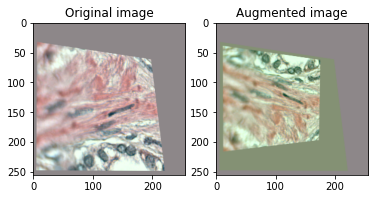

In [18]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [20]:
from torch.nn.modules import MSELoss
from utils_eval import NCESoftmaxLoss, NCECriterion

device = torch.device("cuda:2")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters
# Increasing nce_m improves stability
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01   # ori 0.01
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/s223242/.cache/torch/hub/pytorch_vision_v0.4.0


In [22]:
model_dir = "./models/Dataset_HPC"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [24]:
"""TO LOAD:"""
model_file = None
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

## 4) Train

In [25]:
import time
from scipy.stats import spearmanr

from utils_eval import AverageMeter

def train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:2")):
    """
    One epoch training
    """
    model.train()
    contrast.train()

    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    image_loss_meter = AverageMeter()
    gene_loss_meter = AverageMeter()
    image_prob_meter = AverageMeter()
    gene_prob_meter = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(train_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        out_image, out_gene = contrast(feat_image, feat_gene, index)
        
        # print("features:", feat_image, feat_gene, "\n")
        # print("outs: ", out_image, out_gene, "\n")
        
        image_loss = criterion_image(out_image)
        gene_loss = criterion_gene(out_gene)
        image_prob = out_image[:, 0].mean()
        gene_prob = out_gene[:, 0].mean()

        loss = image_loss + gene_loss

        # ===================backward=====================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        torch.nn.utils.clip_grad_norm_(contrast.parameters(), gradient_clip)
        optimizer.step()

        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        image_loss_meter.update(image_loss.item(), batch_size)
        image_prob_meter.update(image_prob.item(), batch_size)
        gene_loss_meter.update(gene_loss.item(), batch_size)
        gene_prob_meter.update(gene_prob.item(), batch_size)

        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()

        # print info
        if (idx + 1) % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'
                  # 'BT {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                  # 'DT {data_time.val:.3f} ({data_time.avg:.3f})\t'
                  'loss {loss.val:.3f} ({loss.avg:.3f})\t'
                  'image_p {image_probs.val:.3f} ({image_probs.avg:.3f})\t'
                  'gene_p {gene_probs.val:.3f} ({gene_probs.avg:.3f})'.format(
                   epoch, idx + 1, len(train_loader), batch_time=batch_time,
                   data_time=data_time, 
                   loss=losses, 
                   image_probs=image_prob_meter,
                   gene_probs=gene_prob_meter))
            # print(out_image.shape)
            sys.stdout.flush()
            
        # ===================debug======================
        if np.isnan(image_prob_meter.val):
            print(list(model.parameters()))
            print(feat_image)
            print(feat_gene)
            print(out_image)
            
            raise Exception("Nan detected")
            break

    return losses.avg, image_loss_meter.avg, image_prob_meter.avg, gene_loss_meter.avg, gene_prob_meter.avg


def test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:2")):
    """Testing"""
    model.eval()
    contrast.eval()

    batch_time = AverageMeter()
    data_time = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(test_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        with torch.no_grad():
            feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])
        
        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()
        
    # Normalize & calculate correlation
    feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
    feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
    corr = []
    for i in range(feat_images.shape[1]):
        corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
    if epoch % 100 == 0:
        plt.hist(corr, bins=30)
        plt.show()
    print("Val epoch {}, average corr {}".format(epoch, np.average(corr)))

    return np.average(corr)

Epoch: [0][10/175]	loss 58.411 (60.642)	image_p 0.014 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][20/175]	loss 48.154 (55.781)	image_p 0.001 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][30/175]	loss 48.550 (53.294)	image_p 0.002 (0.009)	gene_p 0.009 (0.010)
Epoch: [0][40/175]	loss 46.241 (51.756)	image_p 0.001 (0.009)	gene_p 0.008 (0.010)
Epoch: [0][50/175]	loss 43.157 (50.266)	image_p 0.001 (0.012)	gene_p 0.011 (0.011)
Epoch: [0][60/175]	loss 42.576 (48.905)	image_p 0.009 (0.011)	gene_p 0.009 (0.011)
Epoch: [0][70/175]	loss 39.466 (47.617)	image_p 0.038 (0.012)	gene_p 0.008 (0.011)
Epoch: [0][80/175]	loss 35.859 (46.228)	image_p 0.056 (0.013)	gene_p 0.036 (0.012)
Epoch: [0][90/175]	loss 35.244 (44.898)	image_p 0.011 (0.013)	gene_p 0.018 (0.014)
Epoch: [0][100/175]	loss 32.234 (43.719)	image_p 0.031 (0.013)	gene_p 0.042 (0.014)
Epoch: [0][110/175]	loss 29.844 (42.475)	image_p 0.004 (0.013)	gene_p 0.010 (0.015)
Epoch: [0][120/175]	loss 30.343 (41.282)	image_p 0.003 (0.015)	gene_p 0.021 (0.017)
E

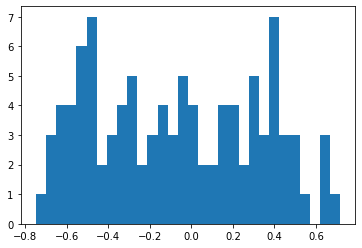

Val epoch 0, average corr -0.07168604383032755
Epoch: [1][10/175]	loss 33.117 (35.966)	image_p 0.000 (0.006)	gene_p 0.001 (0.003)
Epoch: [1][20/175]	loss 32.069 (33.384)	image_p 0.002 (0.010)	gene_p 0.001 (0.003)
Epoch: [1][30/175]	loss 26.493 (32.090)	image_p 0.002 (0.009)	gene_p 0.037 (0.008)
Epoch: [1][40/175]	loss 27.931 (31.523)	image_p 0.008 (0.009)	gene_p 0.031 (0.008)
Epoch: [1][50/175]	loss 26.686 (30.710)	image_p 0.001 (0.010)	gene_p 0.000 (0.009)
Epoch: [1][60/175]	loss 26.000 (30.168)	image_p 0.051 (0.012)	gene_p 0.025 (0.012)
Epoch: [1][70/175]	loss 25.930 (29.837)	image_p 0.020 (0.011)	gene_p 0.000 (0.013)
Epoch: [1][80/175]	loss 27.371 (29.512)	image_p 0.064 (0.013)	gene_p 0.056 (0.015)
Epoch: [1][90/175]	loss 26.783 (29.278)	image_p 0.046 (0.014)	gene_p 0.007 (0.016)
Epoch: [1][100/175]	loss 25.408 (28.933)	image_p 0.012 (0.018)	gene_p 0.051 (0.017)
Epoch: [1][110/175]	loss 25.511 (28.610)	image_p 0.037 (0.020)	gene_p 0.004 (0.018)
Epoch: [1][120/175]	loss 22.676 (28.29

In [ ]:
hist = dict()
hist['loss'] = []
hist['corr_val'] = []
hist['image_loss'] = []
hist['image_prob'] = []
hist['gene_loss'] = []
hist['gene_prob'] = []

save_freq = 1
best_corr = -float("inf")

for epoch in range(1000):
    loss, image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['loss'].append(loss)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    
    corr = test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['corr_val'].append(corr)
    
    # Check if this is the best corr so far
    if corr > best_corr:
        best_corr = corr
        hist_best = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'corr_val': corr
        }
        torch.save(hist_best, os.path.join(model_dir, "epoch_best.pt"))
    
    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch }
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

In [ ]:
torch.save(hist, os.path.join(model_dir, "hist.pt"))

# Session Info

In [58]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2019.3.9
chardet==3.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==2.8
image-registration==0.2.4
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel==5.1.0
ipython==7.4.0
ipython-genutils==0.2.0
ipywidgets==7.4.2
isodate==0.6.0
jedi==0.13.3
Jinj